A/B Testing Dataset:
  Group  Users  Conversions
0     A   1000          120
1     B   1000          150

Group A Conversion Rate: 12.0 %
Group B Conversion Rate: 15.0 %

Group A vs Group B:
12.0 % vs 15.0 %

H0: pA = pB
H1: pA != pB

Z-statistic: -1.963049807622355
P-value: 0.04964038686536878

Decision: Reject H0
Conclusion: There is a significant difference between Group A and Group B.


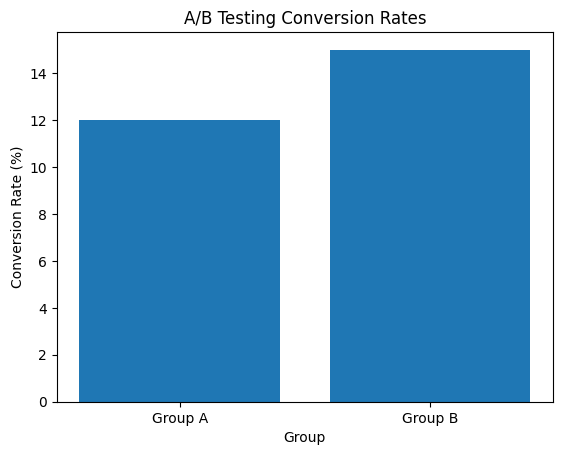

In [3]:
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest
import matplotlib.pyplot as plt

# 1. Load dataset
df = pd.read_csv("ab_testing.csv")

# 2. Display data
print("A/B Testing Dataset:")
print(df)

# 3. Calculate conversion rate for Group A
users_A = df.loc[df["Group"] == "A", "Users"].iloc[0]
conversions_A = df.loc[df["Group"] == "A", "Conversions"].iloc[0]
rate_A = conversions_A / users_A

# 4. Calculate conversion rate for Group B
users_B = df.loc[df["Group"] == "B", "Users"].iloc[0]
conversions_B = df.loc[df["Group"] == "B", "Conversions"].iloc[0]
rate_B = conversions_B / users_B

print("\nGroup A Conversion Rate:", rate_A * 100, "%")
print("Group B Conversion Rate:", rate_B * 100, "%")

# 5. Compare conversion rates
print("\nGroup A vs Group B:")
print(rate_A * 100, "% vs", rate_B * 100, "%")

# 6. Null Hypothesis
print("\nH0: pA = pB")

# 7. Alternative Hypothesis
print("H1: pA != pB")

# 8. Significance level
alpha = 0.05

# 9. Perform two-proportion z-test
conversions = [conversions_A, conversions_B]
users = [users_A, users_B]

result = proportions_ztest(
    conversions,
    users,
    alternative="two-sided"
)

z_stat = float(result[0])
p_value = float(result[1])

# 10. Display p-value
print("\nZ-statistic:", z_stat)
print("P-value:", p_value)

# 11 & 12. Decision
if p_value < alpha:
    print("\nDecision: Reject H0")
    print("Conclusion: There is a significant difference between Group A and Group B.")
else:
    print("\nDecision: Do not reject H0")
    print("Conclusion: There is no significant difference between Group A and Group B.")

# 13. Bar chart
plt.bar(
    ["Group A", "Group B"],
    [rate_A * 100, rate_B * 100]
)

plt.xlabel("Group")
plt.ylabel("Conversion Rate (%)")
plt.title("A/B Testing Conversion Rates")
plt.show()

In [ ]:
import pandas as pd
from scipy import stats

# 1. Load dataset
df = pd.read_csv("supermarket_sales.csv")

# 2. Display first five records
print("First 5 Records:")
print(df.head())

# 3. Select revenue column
revenue = df["revenue"]

# 4. Check for missing values
print("\nMissing Values:")
print(revenue.isnull().sum())

revenue = revenue.dropna()

# 5. Calculate mean revenue
mean_revenue = revenue.mean()
print("\nMean Revenue:", mean_revenue)

# 6 & 7. Null Hypothesis
print("\nH0: μ = 1500")

# 8. Alternative Hypothesis
print("H1: μ != 1500")

# 9. Perform two-proportion z-test
conversions = [conversions_A, conversions_B]
users = [users_A, users_B]

test_result = proportions_ztest(
    conversions,
    users,
    alternative="two-sided"
)

z_stat = float(test_result[0])
p_value = float(test_result[1])
alpha = 0.05

# 10. Display p-value
print("\nZ-statistic:", z_stat)
print("P-value:", p_value)

# 11 & 12. Decision
decision = p_value < alpha

if decision:
    print("\nDecision: Reject H0")
    print("Conclusion: There is a significant difference between Group A and Group B.")
else:
    print("\nDecision: Do not reject H0")
    print("Conclusion: There is no significant difference between Group A and Group B.")

First 5 Records:
    invoice_id branch       city customer_type gender_customer  \
0  750-67-8428      A     Yangon        Member          Female   
1  226-31-3081      C  Naypyitaw        Normal          Female   
2  631-41-3108      A     Yangon        Normal            Male   
3  123-19-1176      A     Yangon        Member            Male   
4  373-73-7910      A     Yangon        Normal            Male   

             product_line  unit_cost  quantity  5pct_markup   revenue  \
0       Health and beauty      74.69         7      26.1415  548.9715   
1  Electronic accessories      15.28         5       3.8200   80.2200   
2      Home and lifestyle      46.33         7      16.2155  340.5255   
3       Health and beauty      58.22         8      23.2880  489.0480   
4       Sports and travel      86.31         7      30.2085  634.3785   

        date   time payment_method    cogs    gm_pct  gross_income  rating  
0   01/05/19  13:08        Ewallet  522.83  4.761905       26.1415    